# Test: Title

## Milestone 1: Project Plan & Exploratory Analysis
**Author:** Maya Gore  
**Github:**   
**Data Source:** City of New Orleans, [Geocode API]  

---
### Project Overview & Goal
[Intro on new orleans and STRs]  
  
**Central Research Quesion:**  Do STR permit regulations cause units to transition into long-term housing supply, (and, do neighborhoods see measurable changes in occupancy, rental rates, or housing values?)


### Project Datasets   
  
#### 1. STR Permit Applications, City of New Orleans *(primary dataset for M1)*
**Source:** [link]  
**Unit of observation:** individual permit application  
**Time period:** 2017 to 2025, 35,952 applications   
  
This is the core dataset and the primary data examined for Milestone 1. It contains the application for every STR permit in New Orleans including withdrawls and rejections, and captures the permit type, residential subtype, status (and date of issue, date of application), operator name, capacity, and GPS coordinates. It captures the regulatory history of the STR market in New Orleans.  
  
This dataset can answer questions about whether STR permit activity changed around periods of regulatory change. 

#### 1a. Census Bureau reverse geocoding API  
**Source:**  
  
Each set of GPS coordinates from the STR permit application dataset were matched to their census tract utilizing this API.  
  
#### 2. American Community Survey (ACS) 5-Year Estimates, IPUMS *(pending M2)*  
**Source:** [ipums]  
**Unit of observation:** census track panel data by year (2014-2024)  
  
The ACS provides tract-level housing and demographic variables included total housing units within the tract, owner- and renter-occupation status, median rent, median home value, and median houshold income.  
  
This dataset will be utilized to obeserve housing market changes around the regulatory cutoff and downstream housing supply effects. It will help answer if renter occupancy rate increase in high-STR areas after regulation, and whether median rents declined.  
  
#### 3. Inside Airbnb New Orleans listings *(pending M2)*  
**Source:**  
**Unit of observation:** Airbnb listing  
  
As referenced, there have been enforcement issues aurrounding STR permitting regulations. Due to potential discrepancies between lisitngs and permits, this dataset can be compared to STR permits to ask similar quesitons about changes to listings surrounding regulatory cutoffs. 

---
### Extract, Transform & Load: STR Permits

In [4]:
%pip install numpy pandas requests
import re
import time
import numpy as np
import pandas as pd
import requests
import os
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Step 1. Load csv & clean permit variables.  
  
Ensure tidy data principles by checking the following:  
* Each row is one permit application  
* Each column is one variable  
* categorical strings encoded  
* Date strings parsed  
* GPS string separated into latitude and longitude (for Step 2)  

Set the directory:

In [6]:
os.chdir("/Users/mayagore/Library/CloudStorage/OneDrive-TulaneUniversity/26S Data Science/Project/Data")

In [ ]:
df = pd.read_csv("Short-Term_Rental_Permit_Applications_20250929.csv")

# check what's in the dataset
df.head()

# fix naming inconsistencies and make column names more code-friendly
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

# fix permit number formatting and convert to numeric (coercing errors to NaN)
df["permit_number"] = pd.to_numeric(df["permit_number"], errors="coerce")

## Set categorical variable mapping as integer codes------------
# permit type map
perm_type_map = {
    "Interim STR":                            1,
    "Non-Commercial STR - Special Exception": 2,
    "Non-Commercial Short Term Rental":       3,
    "Short Term Rental":                      4,
    "Short Term Rental Commercial Owner":     5,
    "Short Term Rental Residential Owner":    6,
    "N/A":                                    0,
}
df["perm_type"] = df["permit_type"].map(perm_type_map)

# residential subtype map
res_type_map = {
    "Accessory STR":            1,
    "Commercial STR":           2,
    "Interim":                  3,
    "Residential Large Unit":   4,
    "Residential Partial Unit": 5,
    "Residential Small Unit":   6,
    "Temporary STR":            7,
    "N/A":                      0,
}
df["res_type"] = df["residential_subtype"].map(res_type_map)

# permit status map
status_map = {
    "Denied":    1,
    "Duplicate": 2,
    "Expired":   3,
    "Issued":    4,
    "Pending":   5,
    "Revoked":   6,
    "Withdrawn": 7,
}
df["status"] = df["current_status"].map(status_map)
#---------------------------------------------------

# expired status dummy variable
df["exp_"] = df["expired"].map({"Yes": 1, "No": 0})

# clean date variables
df["exp_date"] = pd.to_datetime(df["expiration_date"], errors="coerce")
df["iss_date"] = pd.to_datetime(df["issue_date"], errors="coerce")
df["app_date"] = pd.to_datetime(df["application_date"], errors="coerce")

# create month-year and year variables for application date for time-series grouping
df["app_moyr"] = df["app_date"].dt.to_period("M")
df["app_year"] = df["app_date"].dt.year

# encode string IDs
for src, dst in [("operator_name", "operator_id"), ("operator_permit_number", "operator_permit_id")]:
    df[dst] = df[src].astype("category").cat.codes + 1  # +1 to avoid confusion with -1 for NaN

# parse location into lat/lon variables
def parse_latlon(s):
    try:
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(s))
        if len(nums) == 2:
            return float(nums[0]), float(nums[1])
    except Exception:
        pass
    return np.nan, np.nan
laton = df["location"].apply(parse_latlon)
df["latitude"] = laton.apply(lambda x: x[0])
df["longitude"] = laton.apply(lambda x: x[1])

# check the cleaned dataset
df.head()
#df.dtypes

,permit_number,address,permit_type,residential_subtype,current_status,expired,expiration_date,bedroom_limit,guest_occupancy_limit,link,...,exp_,exp_date,iss_date,app_date,app_moyr,app_year,operator_id,operator_permit_id,latitude,longitude
0,NaN,NaN,Short Term Rental,NaN,Pending,No,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,0,NaT,NaT,NaT,NaT,NaN,0,0,29.920602,-90.110274
1,NaN,NaN,Short Term Rental,NaN,Denied,Yes,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,NaT,2023-01-26,2023-01,2023.0,0,0,28.098891,-101.517799
2,NaN,212 Loyola Ave Unit 1205,Short Term Rental,Commercial STR,Revoked,Yes,NaN,NaN,4.0,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,2018-04-10,2018-04-10,2018-04,2018.0,0,0,29.954276,-90.074632
3,NaN,NaN,Short Term Rental,Accessory STR,Withdrawn,Yes,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,NaT,2017-10-09,2017-10,2017.0,2080,0,29.953576,-90.053063
4,NaN,416 Park Blvd,Short Term Rental,Accessory STR,Denied,Yes,NaN,NaN,NaN,https://onestopapp.nola.gov/Redirect.aspx?Sear...,...,1,NaT,NaT,2017-04-04,2017-04,2017.0,0,0,29.939830,-90.051158


---
### Step 2. Geocode coordinates to census tracts.
**Please note: the geocoding portion takes a few hours. This section exports a STRs_cleaned.csv which has been uploaded to the Github and which can be read in directly at Step 3!**  
  
The STR permits include addesses & coordinates, but no zipcode or census tract id. I want to ultimately merge this data with ACS, so I need to merge in a geographical unit to match the ACS unti of observation.

In [3]:
nola_mask = (
    (df["latitude"] >= 29.85) & (df["latitude"] <= 30.10) &
    (df["longitude"] >= -90.30) & (df["longitude"] <= -89.90)
)
print(nola_mask.sum())

total_obs      = len(df)
invalid_coords = df["latitude"].isna().sum()
outside_nola   = (~df.apply(
    lambda r: nola_mask.loc[r.name], axis=1
)).sum()
inside_nola    = total_obs - outside_nola
print(f"Total STR observations:          {total_obs}")
print(f"Invalid/missing coordinates:     {invalid_coords}")
print(f"Outside New Orleans bounds:      {outside_nola}")
print(f"Inside New Orleans bounds:       {inside_nola}")

35596
Total STR observations:          35952
Invalid/missing coordinates:     0
Outside New Orleans bounds:      356
Inside New Orleans bounds:       35596


In [4]:
coords = (
    df[nola_mask][["latitude", "longitude"]]
    .drop_duplicates()
)
print(f"\nUnique coordinate pairs to geocode: {len(coords)}")

def geocode_coord(lat, lon):
    """Return 11-digit census tract GEOID, or '' on failure."""
    url = ("https://geocoding.geo.census.gov/geocoder/geographies/coordinates"
        f"?x={lon}&y={lat}&benchmark=Public_AR_Current&vintage=Current_Current&format=json"
    )
    for _ in range(3):  # retry up to 3 times
        try:
            r = requests.get(url, timeout=5).json()
            geos = r["result"]["geographies"].get("Census Tracts", [])
            if geos:
                return geos[0]["GEOID"]
            return ""
        except Exception:
            time.sleep(1)  # wait before retrying
    return ""

coord_to_tract = {}
for i, row in coords.iterrows():
    lat, lon = row["latitude"], row["longitude"]
    coord_to_tract[(lat, lon)] = geocode_coord(lat, lon)
    if i % 100 == 0:
        print(f"Processed {i} pairs")


Unique coordinate pairs to geocode: 18176
Processed 0 pairs
Processed 100 pairs
Processed 200 pairs
Processed 300 pairs
Processed 400 pairs
Processed 500 pairs
Processed 600 pairs
Processed 700 pairs
Processed 800 pairs
Processed 1000 pairs
Processed 1100 pairs
Processed 1200 pairs
Processed 1300 pairs
Processed 1500 pairs
Processed 1700 pairs
Processed 1800 pairs
Processed 1900 pairs
Processed 2000 pairs
Processed 2100 pairs
Processed 2200 pairs
Processed 2400 pairs
Processed 2600 pairs
Processed 2700 pairs
Processed 2800 pairs
Processed 2900 pairs
Processed 3000 pairs
Processed 3200 pairs
Processed 3300 pairs
Processed 3500 pairs
Processed 3600 pairs
Processed 3700 pairs
Processed 3900 pairs
Processed 4000 pairs
Processed 4100 pairs
Processed 4300 pairs
Processed 4400 pairs
Processed 4500 pairs
Processed 4600 pairs
Processed 4800 pairs
Processed 4900 pairs
Processed 5000 pairs
Processed 5100 pairs
Processed 5300 pairs
Processed 5500 pairs
Processed 5800 pairs
Processed 5900 pairs
Pr

delete?:

In [5]:
start = time.time()
for i, row in coords.iterrows():
    lat, lon = row["latitude"], row["longitude"]
    coord_to_tract[(lat, lon)] = geocode_coord(lat, lon)
    if i % 100 == 0 and i > 0:
        elapsed = time.time() - start
        rate = elapsed / i
        remaining = rate * (len(coords) - i)
        print(f"  {i}/{len(coords)} — est. {remaining/60:.1f} min remaining")

  100/18176 — est. 108.3 min remaining
  200/18176 — est. 123.5 min remaining
  300/18176 — est. 132.3 min remaining
  400/18176 — est. 132.9 min remaining
  500/18176 — est. 133.0 min remaining
  600/18176 — est. 133.0 min remaining
  700/18176 — est. 132.3 min remaining
  800/18176 — est. 132.6 min remaining
  1000/18176 — est. 131.1 min remaining
  1100/18176 — est. 130.2 min remaining
  1200/18176 — est. 129.9 min remaining
  1300/18176 — est. 129.4 min remaining
  1500/18176 — est. 126.7 min remaining
  1700/18176 — est. 125.0 min remaining
  1800/18176 — est. 124.1 min remaining
  1900/18176 — est. 123.0 min remaining
  2000/18176 — est. 121.7 min remaining
  2100/18176 — est. 120.8 min remaining
  2200/18176 — est. 119.7 min remaining
  2400/18176 — est. 117.7 min remaining
  2600/18176 — est. 115.0 min remaining
  2700/18176 — est. 114.0 min remaining
  2800/18176 — est. 112.4 min remaining
  2900/18176 — est. 111.1 min remaining
  3000/18176 — est. 109.7 min remaining
  3200/1

In [7]:
# match GEOIDs back to main dataframe
df["tract_geoid"] = df.apply(
    lambda row: coord_to_tract.get((row["latitude"], row["longitude"]), ""),
    axis=1
)   

In [ ]:
# format GEOID as a string--this is important for merging with census data later
df["tract_geoid"] = df["tract_geoid"].astype(str).str.zfill

In [ ]:
## OUTPUT
df.to_csv("STRs_cleaned.csv", index=False)


✔ Saved STRs_cleaned.csv — ready for ACS merge


---
### Step 3. Regulation Timing and Trends
I am reading in the saved .csv output from step 3 above with the census tract GEOIDs. This is to simpligy and cut out repeat runs of the time-consuing geocoding process.

Regulations went into effect in April of 2018 and March of 2023. Here I am creating dates for those cutoffs.

In [7]:
# read in the updated dataset with the census tract GEOIDs
df = pd.read_csv("STRs_cleaned.csv")
df["app_date"] = pd.to_datetime(df["app_date"], errors="coerce")
df["app_moyr"] = df["app_date"].dt.to_period("M")
df["app_year"] = df["app_date"].dt.year

In [8]:
# drop duplicates from status_map
df = df[df["status"] != 2] # 2 = 'duplicate'
df = df[df["status"] != 7] # 7 = 'withdrawn'
df = df[df["status"].notna()] 

# set regulation periods (April 2018 ordinance & March 2023 ordinance)
reg_23_cutoff = pd.Period("2023-03", freq="M")      # March 2023
reg_18_cutoff = pd.Period("2018-04", freq="M")      # April 2018

df["reg_23"] = (df["app_moyr"] >= reg_23_cutoff).astype(int)
df["reg_18"] = (df["app_moyr"] >= reg_18_cutoff).astype(int)        

print(df[["reg_18", "reg_23"]].describe())

# create permit lengths 
df["exp_date"] = pd.to_datetime(df["exp_date"], errors="coerce")
df["next_app_date"] = pd.to_datetime(df["next_app_date"], errors="coerce")

df["days_to_next"] = (df["next_app_date"] - df["exp_date"]).dt.days

             reg_18        reg_23
count  33174.000000  33174.000000
mean       0.774522      0.233315
std        0.417903      0.422948
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      0.000000
75%        1.000000      0.000000
max        1.000000      1.000000


KeyError: 'next_app_date'

---
## Exploratory Data Analysis

**A. Status:**  Applications by status & calculating approval rates

In [9]:
## Are expired permits being replaced by new applications at the same address?
# Sort by address and application date
df_sorted = df.sort_values(["address", "app_date"])

# For each expired permit, check if a new application appears at the same address afterward
df["next_app_date"] = df_sorted.groupby("address")["app_date"].shift(-1)
df["next_status"]   = df_sorted.groupby("address")["status"].shift(-1)

# Gap between expiration and next application
df["days_to_next"] = (df["next_app_date"] - df["exp_date"]).dt.days

# Look at the distribution of this gap for expired permits
expired = df[df["status"] == 3]
print(expired["days_to_next"].describe())

count    13011.000000
mean        93.278226
std        277.822964
min       -999.000000
25%        -23.000000
50%          3.000000
75%        159.000000
max       2357.000000
Name: days_to_next, dtype: float64


In [10]:
# Because it looks like expired permits are often followed by new applications at the same address, create variable to flag these cases vs exits
df["exp_followed_by_app"] = ((df["status"] == 3) & (df["days_to_next"] >= 0) & (df["days_to_next"] <= 180)).astype(int)
print(df["exp_followed_by_app"].value_counts())

exp_followed_by_app
0    29273
1     3901
Name: count, dtype: int64


**B. Operator Size Distribution:** how many units do operators hold? I want to capture the number of units permitted by individual operators, capturing properties with continuously renewing permits as one unit.

count    11218.000000
mean         1.881262
std         22.106338
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       2289.000000
Name: address, dtype: float64


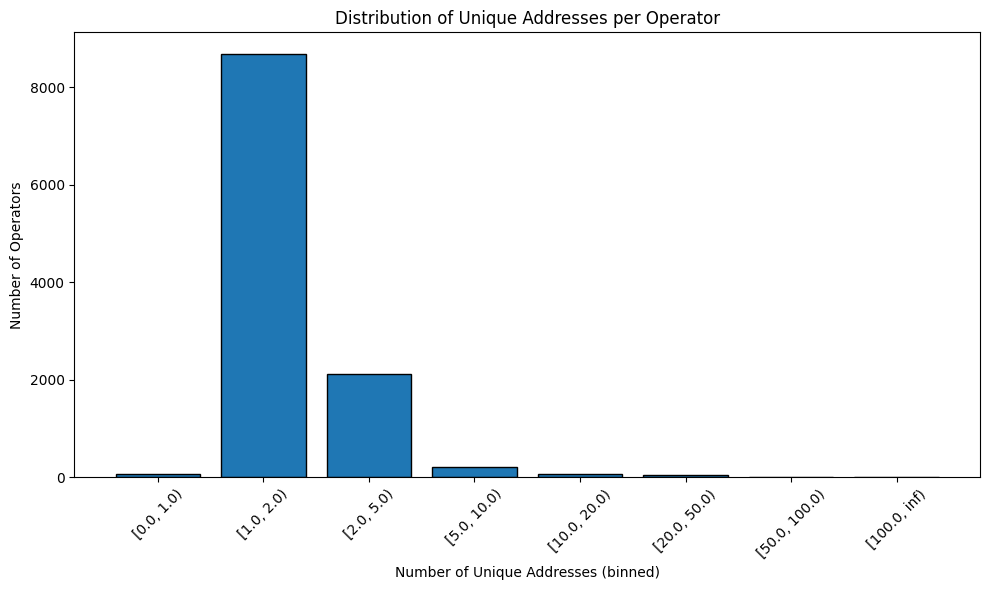

In [14]:
# count the number of unique addresses by operator
address_counts = df.groupby("operator_id")["address"].nunique().sort_values(ascending=False)
print(address_counts.describe())

# visualize distribution of unique addresses per operator
buckets = pd.cut(address_counts, bins=[0, 1, 2, 5, 10, 20, 50, 100, np.inf], right=False)
bucket_counts = buckets.value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(bucket_counts.index.astype(str), bucket_counts.values, edgecolor="k")
plt.title("Distribution of Unique Addresses per Operator")
plt.xlabel("Number of Unique Addresses (binned)")
plt.ylabel("Number of Operators")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**C. Applications over Time:** How do the number of applications change over time relative to regulatory changes?

---  
## Next Steps   